# Forest Patch Prototype

**Strategy**: disconnect existing forest by overlaying a binary noise mask that converts selected forest tiles to grassland.

1. Start from the baseline terrain (all original tiles intact)
2. Generate Gaussian-smoothed blob noise over the map
3. Forest tiles where noise < `blob_threshold` are converted to grassland, punching holes in the forest

**Three parameters:**
- `forest_threshold` — heightmap cutoff: only forest tiles with height < this value are affected. Default 0.6 = all forest. Lower = protect high-elevation forest
- `blob_sigma` — Gaussian blur radius in pixels. Bigger = larger connected clearings; smaller = noisier, finer-grained fragmentation
- `blob_threshold` — fraction of forest to erase. Higher = more forest removed. Range: `[0, 1]`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from cogniland.env.islands import colorize
from cogniland.env.types import EnvConfig, MapGenConfig
from cogniland.env.dataset import MapDataset

In [2]:
# ── Compiled terrain (thresholds, colors, names) ──────────────────────────────
config   = EnvConfig(map_generation=MapGenConfig(seed=42))
compiled = config.compile_terrain('cpu')

thresholds = compiled.thresholds.numpy()   # [9] ascending
colors     = compiled.color_lut.numpy()    # [9, 3] uint8
names      = compiled.terrain_names

FOREST_IDX    = names.index('forest')     # 6
GRASSLAND_IDX = names.index('grassland')  # 5

print(f"Terrain names: {names}")
print(f"Thresholds:    {dict(zip(names, thresholds.round(3)))}")
print(f"Forest idx={FOREST_IDX}, Grassland idx={GRASSLAND_IDX}")

Terrain names: ['ocean', 'deep_water', 'water', 'beach', 'sandy', 'grassland', 'forest', 'rocky', 'mountains']
Thresholds:    {'ocean': np.float32(0.007), 'deep_water': np.float32(0.025), 'water': np.float32(0.05), 'beach': np.float32(0.06), 'sandy': np.float32(0.1), 'grassland': np.float32(0.25), 'forest': np.float32(0.6), 'rocky': np.float32(0.7), 'mountains': np.float32(1.0)}
Forest idx=6, Grassland idx=5


In [3]:
# ── Core helpers ──────────────────────────────────────────────────────────────

FOREST_LOWER = thresholds[GRASSLAND_IDX]  # 0.25 — lower bound of the forest band
FOREST_UPPER = thresholds[FOREST_IDX]     # 0.60 — upper bound (default)

def to_terrain_idx(hm: torch.Tensor) -> np.ndarray:
    """[H,W] float heightmap → [H,W] int terrain index (same logic as colorize)."""
    h = hm.numpy() if isinstance(hm, torch.Tensor) else hm
    idx = np.full(h.shape, len(thresholds) - 1, dtype=np.int8)
    for k in range(len(thresholds) - 1, -1, -1):
        idx[h < thresholds[k]] = k
    return idx


def terrain_to_rgb(tidx: np.ndarray) -> np.ndarray:
    """[H,W] int terrain index → [H,W,3] uint8 RGB."""
    return colors[tidx].astype(np.uint8)


def blob_noise(size: int, sigma: float, seed: int = 0) -> np.ndarray:
    """Gaussian-smoothed uniform noise in [0,1]."""
    rng  = np.random.RandomState(seed)
    raw  = rng.uniform(0.0, 1.0, (size, size))
    blurred = gaussian_filter(raw, sigma=sigma)
    lo, hi  = blurred.min(), blurred.max()
    return (blurred - lo) / (hi - lo + 1e-9)


def apply_forest_blobs(
    hm:               torch.Tensor,
    forest_threshold:  float,
    blob_sigma:        float,
    blob_threshold:    float,
    seed:              int = 0,
) -> np.ndarray:
    """Disconnect forest by erasing parts of it with blob noise.

    Starts from the baseline terrain. Forest tiles where noise < blob_threshold
    are converted to grassland, fragmenting contiguous forest into patches.
    forest_threshold limits which forest tiles are affected (by height).
    """
    tidx = to_terrain_idx(hm)
    out  = tidx.copy()
    h    = hm.numpy() if isinstance(hm, torch.Tensor) else hm

    target = (tidx == FOREST_IDX) & (h < forest_threshold)

    noise = blob_noise(hm.shape[0], blob_sigma, seed)
    out[target & (noise < blob_threshold)] = GRASSLAND_IDX

    return terrain_to_rgb(out)


def forest_fraction(hm: torch.Tensor) -> float:
    tidx = to_terrain_idx(hm)
    return float((tidx == FOREST_IDX).mean())


def forest_fraction_rgb(rgb: np.ndarray) -> float:
    forest_color = colors[FOREST_IDX]
    mask = np.all(rgb == forest_color, axis=-1)
    return float(mask.mean())


def show(ax, img, title: str, subtitle: str = ''):
    ax.imshow(img if img.ndim == 3 else terrain_to_rgb(img))
    ax.set_title(title, fontsize=9, pad=2)
    if subtitle:
        ax.set_xlabel(subtitle, fontsize=7, labelpad=2)
        ax.xaxis.set_label_position('bottom')
    ax.axis('off')


print(f'Forest band: [{FOREST_LOWER:.2f}, {FOREST_UPPER:.2f})')
print('Helpers ready.')

Forest band: [0.25, 0.60)
Helpers ready.


In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
dataset = MapDataset.load('../data/maps_seed42_train128_val16_test16.pt')
MAPS    = [dataset.train_maps[i] for i in [0, 4, 10, 20]]
LABELS  = ['map 0', 'map 4', 'map 10', 'map 20']

print(f"Loaded {dataset.n_train} train maps. Using 4 representative samples.")
print(f"Baseline forest fractions: {[f'{forest_fraction(m):.2%}' for m in MAPS]}")

Loaded 128 train maps. Using 4 representative samples.
Baseline forest fractions: ['4.07%', '5.93%', '9.02%', '6.61%']


## Tune parameters

Edit the three values below and re-run to see the effect on all 4 maps.

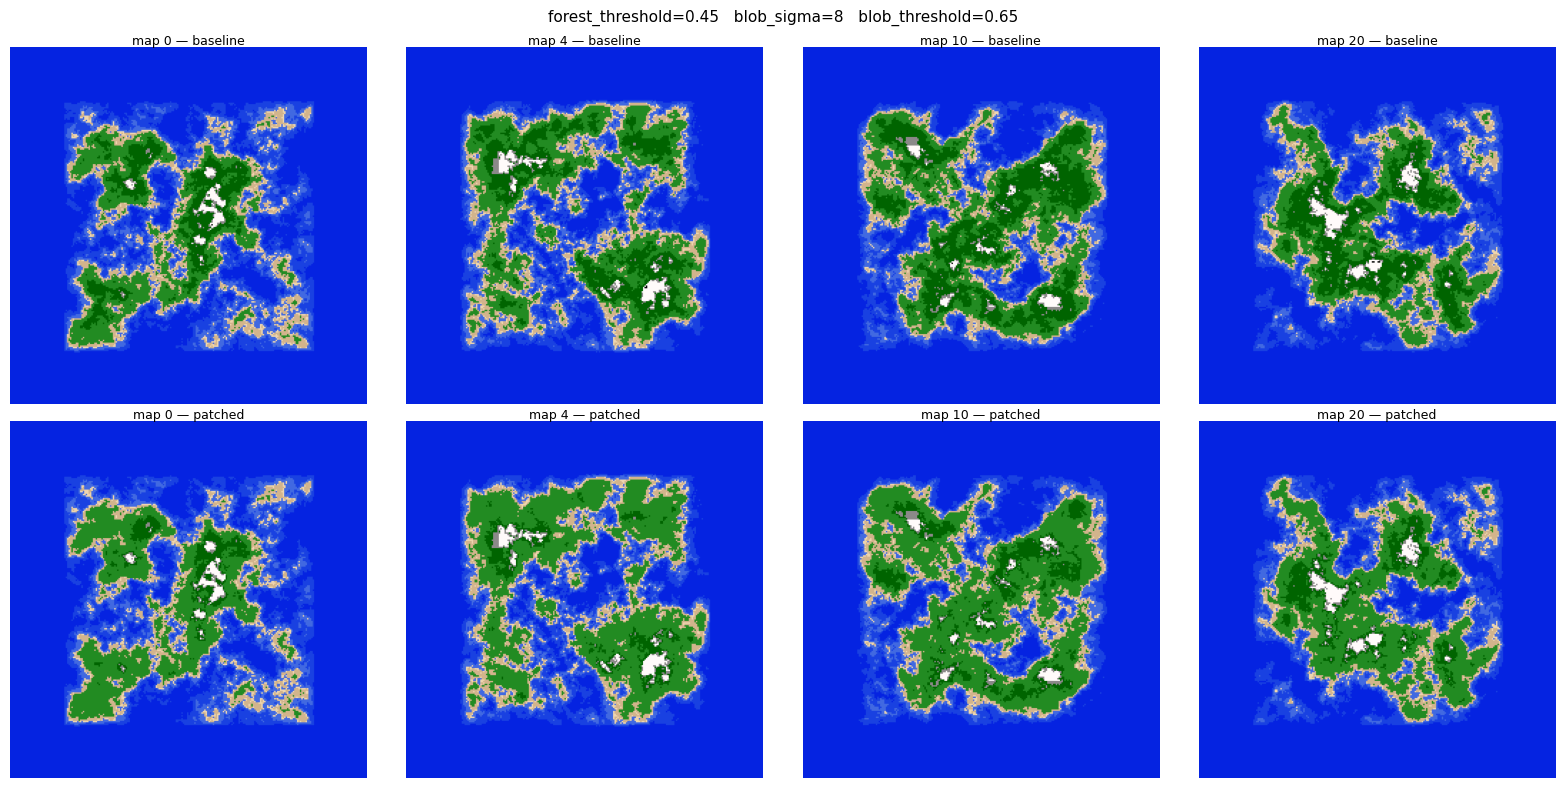

In [15]:
# ── Edit these ────────────────────────────────────────────────────────────────
FOREST_THRESHOLD = 0.45   # [0.25, 0.60] — lower = protect high-elevation forest
BLOB_SIGMA       = 8      # pixels — smaller = noisier fragmentation, larger = bigger clearings
BLOB_THRESHOLD   = 0.65   # [0, 1] — higher = more forest erased
# ──────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    f'forest_threshold={FOREST_THRESHOLD}   blob_sigma={BLOB_SIGMA}   blob_threshold={BLOB_THRESHOLD}',
    fontsize=11,
)
for col, (hm, lbl) in enumerate(zip(MAPS, LABELS)):
    rgb = apply_forest_blobs(hm, FOREST_THRESHOLD, BLOB_SIGMA, BLOB_THRESHOLD)
    show(axes[0, col], colorize(hm, compiled).numpy().astype('uint8'),
         f'{lbl} — baseline', f"forest {forest_fraction(hm):.1%}")
    show(axes[1, col], rgb,
         f'{lbl} — patched', f"forest {forest_fraction_rgb(rgb):.1%}")
plt.tight_layout()
plt.show()

## 3 — Coverage distribution over all training maps

Baseline  forest: mean=5.51%  std=1.09%
Patched   forest: mean=2.20%  std=0.60%


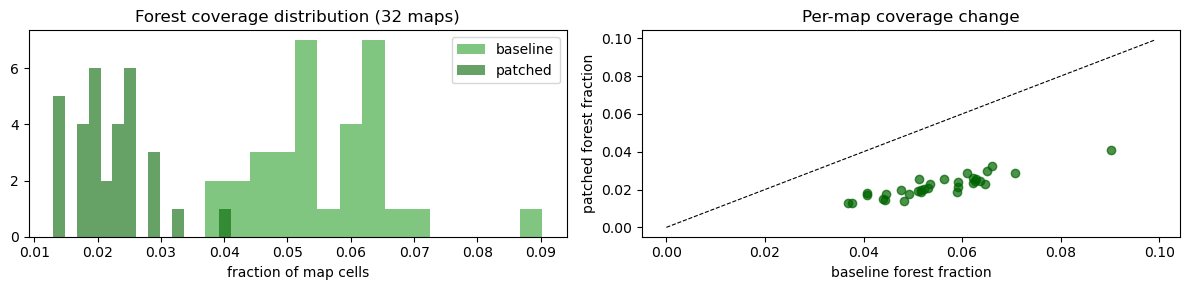

In [16]:
N = min(32, dataset.n_train)
base_fracs    = [forest_fraction(dataset.train_maps[i]) for i in range(N)]
patched_fracs = [
    forest_fraction_rgb(
        apply_forest_blobs(dataset.train_maps[i], FOREST_THRESHOLD, BLOB_SIGMA, BLOB_THRESHOLD)
    )
    for i in range(N)
]

print(f"Baseline  forest: mean={np.mean(base_fracs):.2%}  std={np.std(base_fracs):.2%}")
print(f"Patched   forest: mean={np.mean(patched_fracs):.2%}  std={np.std(patched_fracs):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(base_fracs,    bins=15, alpha=0.6, label='baseline',  color='tab:green')
axes[0].hist(patched_fracs, bins=15, alpha=0.6, label='patched',   color='darkgreen')
axes[0].set_title(f'Forest coverage distribution ({N} maps)')
axes[0].set_xlabel('fraction of map cells')
axes[0].legend()

axes[1].scatter(base_fracs, patched_fracs, alpha=0.7, color='darkgreen')
lim = [0, max(max(base_fracs), max(patched_fracs)) * 1.1]
axes[1].plot(lim, lim, 'k--', lw=0.8)
axes[1].set_xlabel('baseline forest fraction')
axes[1].set_ylabel('patched forest fraction')
axes[1].set_title('Per-map coverage change')

plt.tight_layout()
plt.show()